In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Principal_component_analysis)=
# Principal Component Analysis

*Computing covariance eigenvectors and eigenvalues to identify principal conformational motions.*

The function {func}`molsysmt.structure.principal_component_analysis` performs essential dynamics (PCA) by constructing and diagonalizing the Cartesian atomic positional covariance matrix across a trajectory, extracting the principal collective modes of conformational motion.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.principal_component_analysis`.
:::


## Basic usage

Let's show how to perform principal component analysis on a pentalanine trajectory (fitting frames first to isolate internal conformational dynamics from rotational/translational drift):


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import pyunitwizard as puw
import numpy as np


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])
molsys_fitted = msm.structure.least_rmsd_fit(molsys, selection='all', selection_fit='backbone', reference_structure_index=0)


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We compute the covariance eigenvectors and eigenvalues for heavy atoms using {func}`molsysmt.structure.principal_component_analysis`:


In [4]:
eigenvectors, eigenvalues = msm.structure.principal_component_analysis(molsys_fitted, selection='atom_type!="H"')


In [5]:
print('Eigenvectors shape (modes x 3*atoms):', eigenvectors.shape)
print('Eigenvalues shape (variances):', eigenvalues.shape)
print('Top 3 eigenvalues:', eigenvalues[:3])


Eigenvectors shape (modes x 3*atoms): (90, 90)
Eigenvalues shape (variances): (90,)
Top 3 eigenvalues: [0.5964943862487921 0.14677595412969768 0.1194879104451236] nanometer ** 2


## Cumulative explained variance and eigenvalue spectrum

We compute and plot the individual and cumulative explained variance ratios to assess how many principal components capture the majority of the conformational motion:


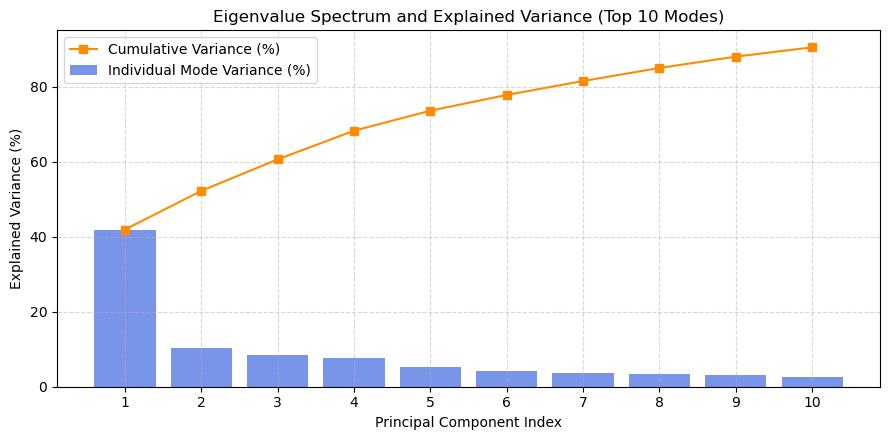

In [6]:
eig_vals = puw.get_value(eigenvalues)
var_ratio = eig_vals / np.sum(eig_vals)
cum_var = np.cumsum(var_ratio)

plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 11), cum_var[:10] * 100, marker='s', color='darkorange', lw=1.5, label='Cumulative Variance (%)')
plt.bar(range(1, 11), var_ratio[:10] * 100, color='royalblue', alpha=0.7, label='Individual Mode Variance (%)')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance (%)')
plt.title('Eigenvalue Spectrum and Explained Variance (Top 10 Modes)')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Projecting structural ensembles onto principal components

We project the trajectory structures onto the top two principal components (PC1 and PC2) to map the low-dimensional conformational energy landscape:


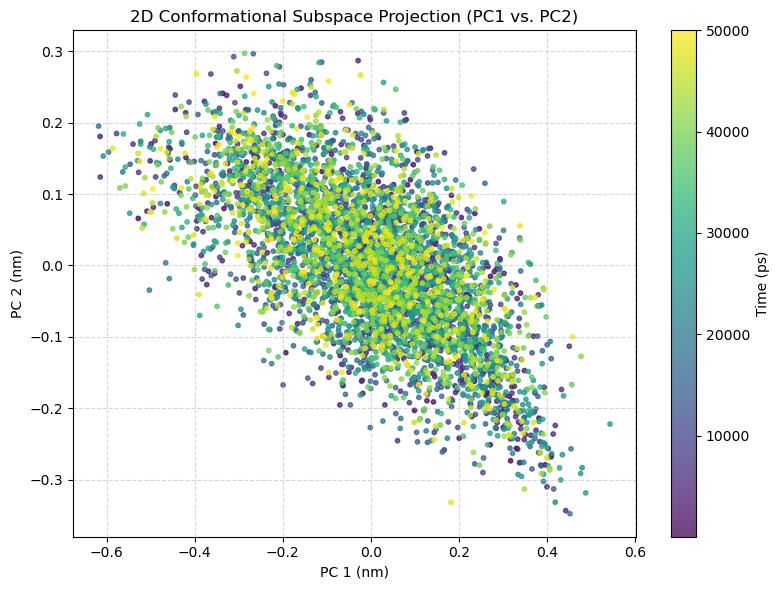

In [7]:
coords = msm.get(molsys_fitted, element='atom', selection='atom_type!="H"', coordinates=True)
coords_val = puw.get_value(coords, to_unit='nm')
n_structures, n_atoms, _ = coords_val.shape
flat_coords = coords_val.reshape(n_structures, n_atoms * 3)
mean_coords = np.mean(flat_coords, axis=0)
centered = flat_coords - mean_coords

pc1_proj = np.dot(centered, eigenvectors[0])
pc2_proj = np.dot(centered, eigenvectors[1])
time = puw.get_value(msm.get(molsys, element='system', time=True), to_unit='ps')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pc1_proj, pc2_proj, c=time, cmap='viridis', s=10, alpha=0.75)
cbar = plt.colorbar(scatter)
cbar.set_label('Time (ps)')
plt.xlabel('PC 1 (nm)')
plt.ylabel('PC 2 (nm)')
plt.title('2D Conformational Subspace Projection (PC1 vs. PC2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query atomic coordinates and system attributes with {func}`molsysmt.basic.get`.
- {ref}`Least RMSD fit <Tutorial_Least_rmsd_fit>`: Superpose coordinates onto a reference structure with {func}`molsysmt.structure.least_rmsd_fit`.
- {ref}`Get RMSD <Tutorial_Get_rmsd>`: Compute root-mean-square deviations with {func}`molsysmt.structure.get_rmsd`.
- {ref}`Get RMSF <Tutorial_Get_rmsf>`: Compute per-atom fluctuations with {func}`molsysmt.structure.get_rmsf`.
- {ref}`Get principal axes <Tutorial_Get_principal_axes>`: Diagonalize the inertia tensor with {func}`molsysmt.structure.get_principal_axes`.
:::
